In [ ]:
# Import necessary libraries for exploratory data analysis (EDA) and plotting
import numpy as np  # Shortened to np
import pandas as pd  # Shortened to pd
import matplotlib.pyplot as plt
import seaborn as sns  # Shortened to sns

# Ensure plots appear in the notebook
%matplotlib inline

## Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

## Model evaluation tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
# Note: In Scikit-Learn 1.2+, "plot_roc_curve" was changed to "RocCurveDisplay"
from sklearn.metrics import RocCurveDisplay

# Print last updated timestamp
import time
print(f"Last updated: {time.asctime()}")

Last updated: Thu Feb  5 21:49:21 2026


In [ ]:
df =pd.read_csv(r'datasets/heart-disease-UCI.csv')

df.head()

# We need to predict whether a person has heart disease or not based on the given features


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
# Exploratory Data Analysis (EDA) Checklist
# Since EDA lacks a predefined methodology, the following checklist can guide you:

# Define Questions: Identify the questions you aim to answer or hypotheses you wish to test.
# Understand Data Types: Analyze the types of data you possess and how to handle different data types effectively.
# Handle Missing Data: Determine missing values within the dataset and implement strategies to address them.
# Detect Outliers: Identify outliers in the data and assess their significance.
# Feature Engineering: Explore opportunities to enhance the dataset by adding, modifying, or removing features.

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
df.target.value_counts()


df.target.value_counts(normalize=True)
# 
# 165 people have heart disease while 138 do not have heart disease

target
1    0.544554
0    0.455446
Name: proportion, dtype: float64

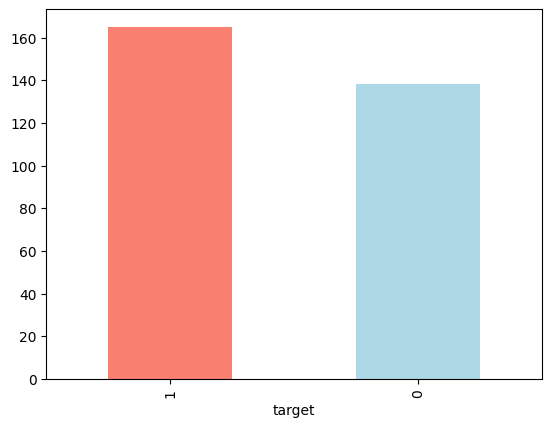

In [ ]:
#plotting this in bar graph

df.target.value_counts().plot(kind='bar', color=['salmon', 'lightblue']);

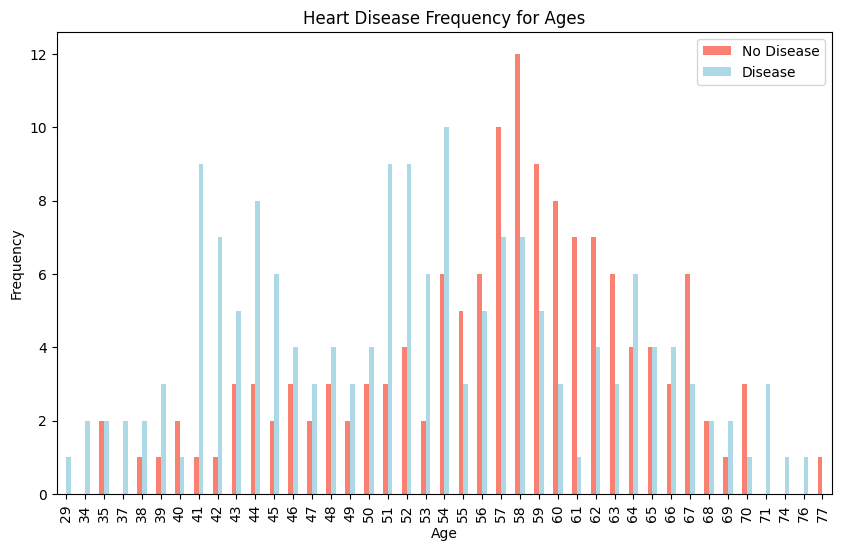

In [ ]:
# we can use pd.crosstab to understand how independent variables are related to target variable

pd.crosstab(df.age, df.target).plot(kind='bar', figsize=(10,6), color=['salmon','lightblue'])
plt.title('Heart Disease Frequency for Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend(['No Disease', 'Disease'])
# plt.xticks(rotation=0);

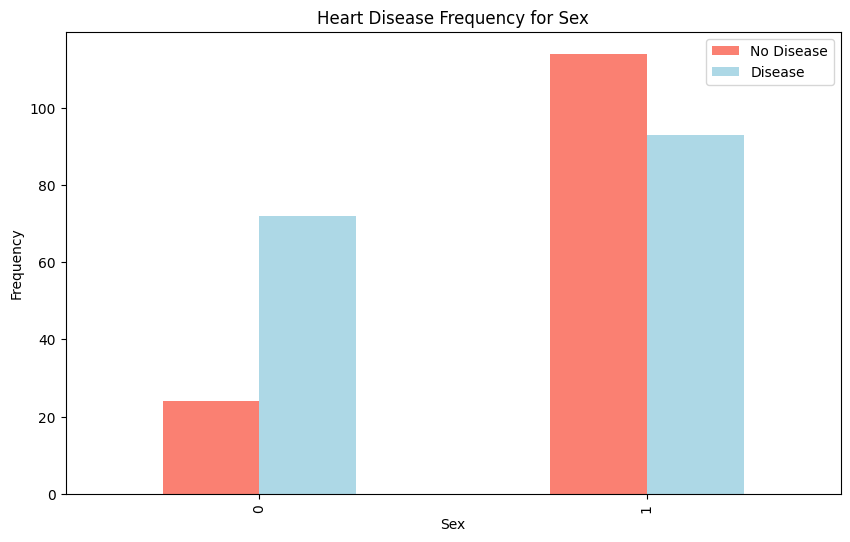

In [ ]:
pd.crosstab(df.sex, df.target).plot(kind='bar', figsize=(10,6), color=['salmon','lightblue'])
plt.title('Heart Disease Frequency for Sex')
plt.xlabel('Sex')
plt.ylabel('Frequency')
plt.legend(['No Disease', 'Disease'])

In [ ]:
pd.crosstab(df.target,df.sex)

# This suggests that 72/(24+72) = 75% of female have heart disease while 93/(114+93) = 45% of male have heart disease. This suggests that
# avg is ~ 60%. This should be the bare minimum accuracy for our model to be useful. 
# If our model cannot achieve an accuracy of 62.5% then it is not better than guessing the most common 
# class (which is having heart disease in this case).

sex,0,1
target,,
0,24,114
1,72,93


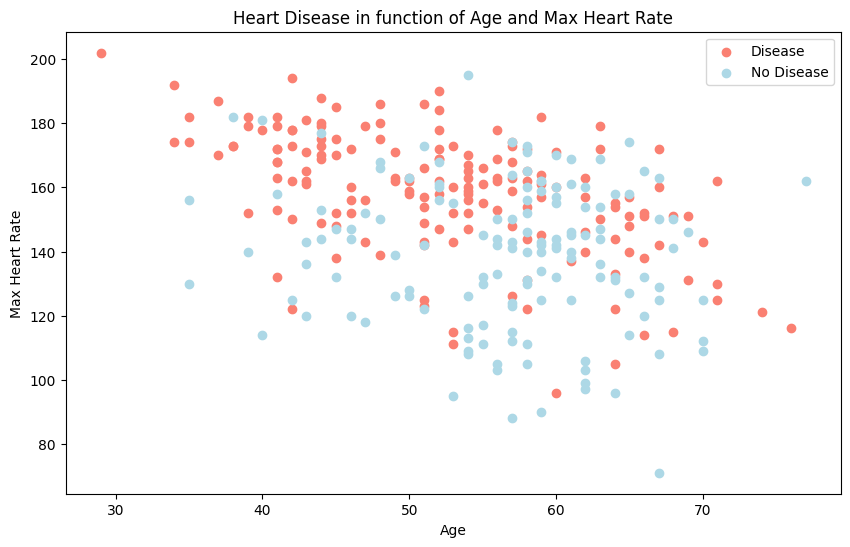

In [ ]:
# Need to find graph between age vs max heart rate (thalach)

plt.figure(figsize=(10,6))

plt.scatter(df.age[df.target==1],
            df.thalach[df.target==1],
            c="salmon")
plt.scatter(df.age[df.target==0],
            df.thalach[df.target==0],
            c="lightblue")

plt.title("Heart Disease in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.legend(["Disease", "No Disease"])
plt.ylabel("Max Heart Rate");

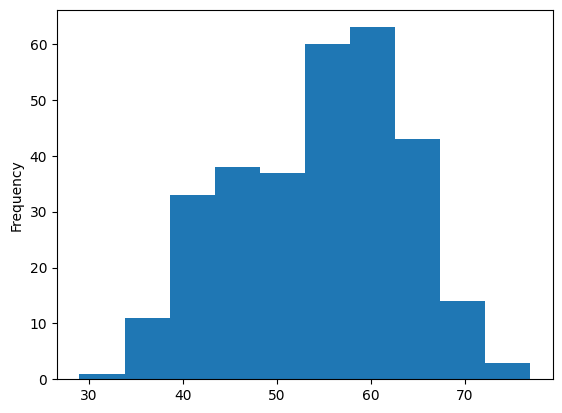

In [ ]:
df.age.plot.hist()

# This is a slightly skewed normal distribution

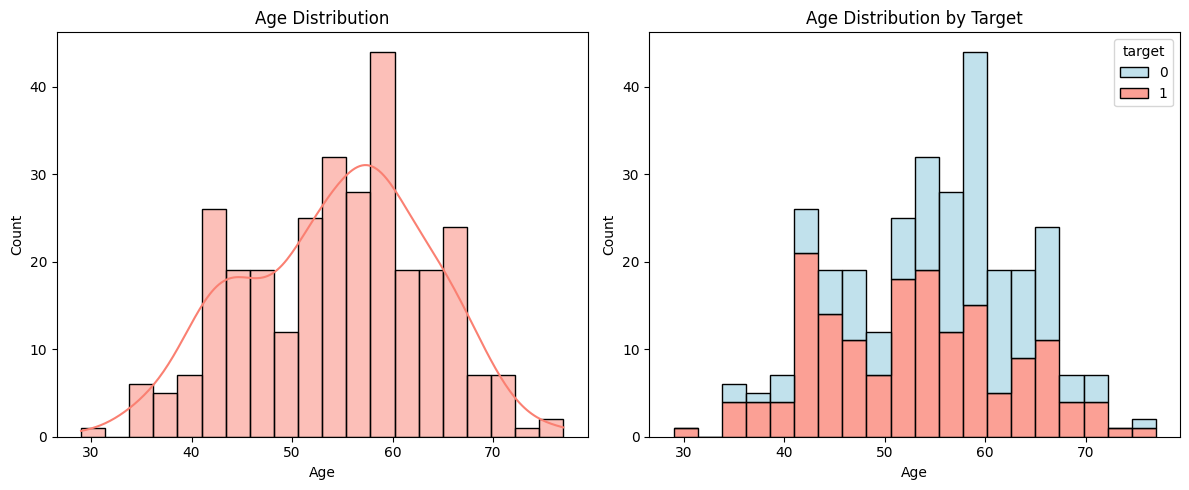

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df['age'], bins=20, kde=True, color='salmon')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1,2,2)
sns.histplot(data=df, x='age', hue='target', bins=20, multiple='stack', palette=['lightblue','salmon'])
plt.title('Age Distribution by Target')
plt.xlabel('Age')
plt.ylabel('Count')

plt.tight_layout()

In [ ]:
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


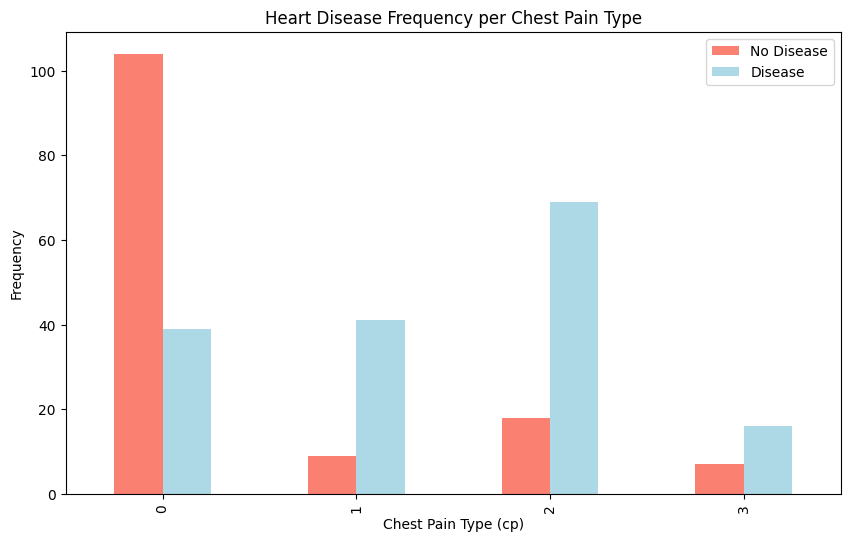

In [ ]:

pd.crosstab(df.cp, df.target).plot(kind='bar', figsize=(10,6), color=['salmon','lightblue'])
plt.title('Heart Disease Frequency per Chest Pain Type')
plt.xlabel('Chest Pain Type (cp)')
plt.ylabel('Frequency')
plt.legend(['No Disease', 'Disease'])
plt.show()

# Chest pain type 2 has more probability of having a heart disease

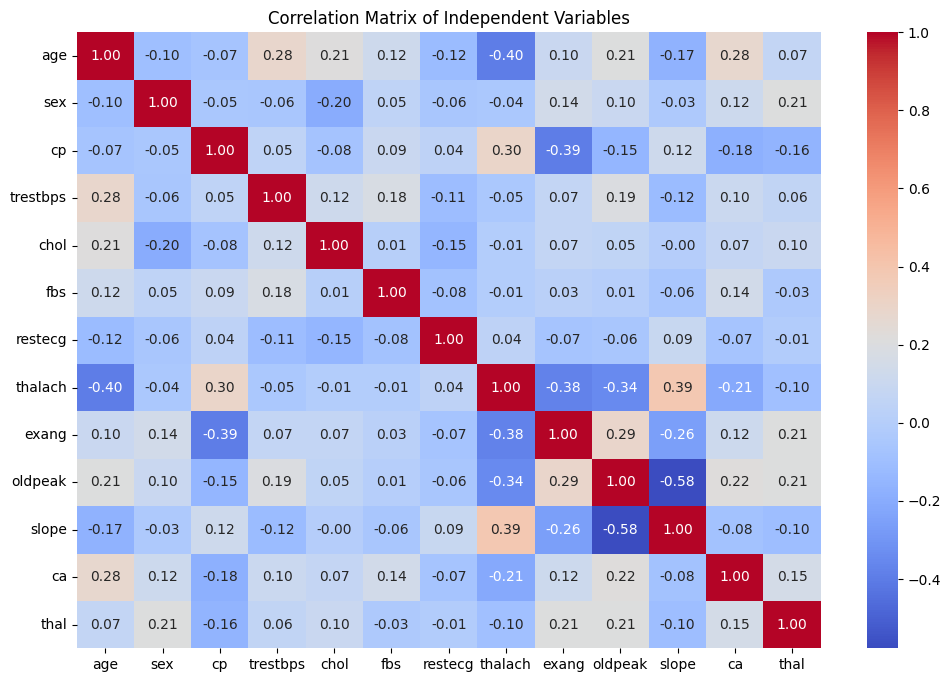

In [ ]:
# Compute correlation matrix for independent variables (excluding 'target')
corr_matrix = df.drop('target', axis=1).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Independent Variables')
plt.show()

In [ ]:
# Model Building

df.head()

X = df.drop("target",axis=1)

y= df.target.values

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
# training and test data splitting
# Random seed for reproducibility
np.random.seed(42)

# Split into train & test set
X_train, X_test, y_train, y_test = train_test_split(X, # independent variables 
                                                    y, # dependent variable
                                                    test_size = 0.2) # percentage of data to use for test set


In [ ]:
# Model Choices
# With our data prepared, we're ready to fit models. We'll be using the following algorithms and comparing their results:

# Logistic Regression: LogisticRegression()
# K-Nearest Neighbors: KNeighborsClassifier()
# Random Forest: RandomForestClassifier()